In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import lineStyles
from mpl_toolkits.mplot3d import Axes3D

In [33]:
def real_f(x,y):
  return (x-y)**2

def f(x,y):
  return 4

def g(x,y):

  if y == 0:
    return x**2

  if y == 2:
    return (x - 2)**2

  if x == 0:
    return y**2

  if x == 1:
    return (y - 1)**2

  return 0




Gauss-seidel method:

In [34]:
def gauss_seidel(w,n,m,h,k,lamb,mu,l,g,f,x,y,tol,n_max):

  while(l < n_max):

    z = (-h**2*f(x[1],y[m-2]) + g(x[0],y[m-2]) +
         lamb*g(x[1],y[m-1]) + lamb*w[1,m-3] +
         w[2,m-2]) / mu

    norm = abs(z - w[1,m-2])
    w[1,m-2] = z


    for i in range(1,n - 2):

      z = (-h**2*f(x[i],y[m-2]) +
           lamb*g(x[i],y[m-1]) +
           w[i-1,m-2] + w[i + 1,m - 2] +
           lamb*w[i,m-3]) / mu

      if abs(w[i,m - 2] - z) > norm:
        norm = abs(w[i,m - 2] - z)

      w[i, m - 2] = z


    z = (-h**2*f(x[n - 2],y[m-2]) +
         g(x[n-1],y[m-2]) +
         lamb*g(x[n-2],y[m - 1]) +
         w[n - 3,m-2] +
         lamb*w[n - 2,m-3]) / mu

    if abs(w[n - 2,m-2] - z) > norm:
      norm = abs(w[n - 2,m-2] - z)

    w[n - 2,m-2] = z


    for j in range(m - 3, 0, -1):

      z = (-h**2*f(x[1],y[j]) +
           g(x[0],y[j]) +
           lamb*w[1,j + 1] +
           lamb*w[1,j - 1] +
           w[2,j]) / mu

      if abs(w[1,j] - z) > norm:
        norm = abs(w[1,j] - z)

      w[1,j] = z


      for i in range(1, n-2):

        z = (-h**2*f(x[i],y[j]) +
             w[i-1,j] +
             lamb*w[i,j+1] +
             w[i + 1,j] +
             lamb*w[i,j-1]) / mu

        if abs(w[i,j] - z) > norm:
          norm = abs(w[i,j] - z)

        w[i,j] = z


      z = (-h**2*f(x[n - 2],y[j]) +
           g(x[n-1],y[j]) +
           w[n-3,j] +
           lamb*w[n - 2,j + 1] +
           lamb*w[n-2,j-1]) / mu

      if abs(w[n-2,j] - z) > norm:
        norm = abs(w[n-2,j] - z)

      w[n-2,j] = z


    z = (-h**2*f(x[1],y[1]) +
         g(x[0],y[1]) +
         lamb*g(x[1],y[0]) +
         lamb*w[1,2] +
         w[2,1]) / mu

    if abs(w[1,1] - z) > norm:
      norm = abs(w[1,1] - z)

    w[1,1] = z


    for i in range(2,n-2):

      z = (-h**2*f(x[i],y[1]) +
           lamb*g(x[i],y[0]) +
           w[i - 1,1] +
           lamb*w[i,2] +
           w[i + 1,1]) / mu

      if abs(w[i,1] - z) > norm:
        norm = abs(w[i,1] - z)

      w[i,1] = z


    z = (-h**2*f(x[n - 2],y[1]) +
         g(x[n - 1],y[1]) +
         lamb*g(x[n-2],y[0]) +
         w[n-3,1] +
         lamb*w[n-2,2]) / mu

    if abs(w[n - 2,1] - z ) > norm:
      norm = abs(w[n-2,1] - z)

    w[n - 2,1] = z


    if norm <= tol:
      return x,y,w

    l += 1

  print("Número máximo excedido")
  return x,y,w


In [35]:
def elipticas(a,b,c,d,m,n,tol,n_max,g,f):

  #Tamanho dos passos
  h = (b - a)/n
  k = (d - c)/m

  #Pontos da malha
  x = np.linspace(a,b,n + 1)
  y = np.linspace(c,d,m + 1)

  #Aproximação
  w = np.zeros(shape = (n + 1,m + 1))

  #Inicialização das condições de contorno
  for i in range(n+1):
    w[i,0] = g(x[i], y[0])
    w[i,m - 1] = g(x[i], y[m])

  for j in range(m+1):
    w[0,j] = g(x[0], y[j])
    w[n - 1,j] = g(x[n], y[j])

  lamb = (h/k)**2
  mu = 2*(1 + lamb)

  x,y,w = gauss_seidel(w,n + 1,m + 1,h,k,lamb,mu,1,g,f,x,y,tol,n_max)

  return w,x,y

In [36]:
w,x,y = elipticas(0,1,0,2,20,20,1e-6,1000,g,f)

Número máximo excedido


<Figure size 1500x800 with 0 Axes>

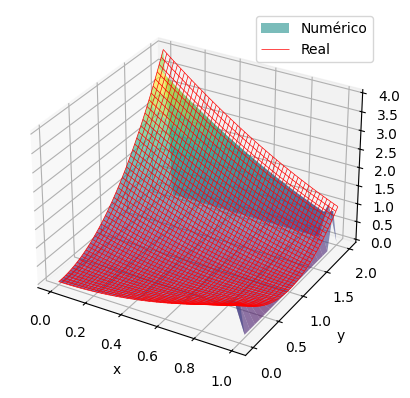

In [37]:
plt.figure(figsize = (15,8))
X, Y = np.meshgrid(x, y)
X_real,Y_real = np.meshgrid(np.linspace(0,1),np.linspace(0,2))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, w.T, cmap='viridis', alpha=0.6, label='Numérico')
ax.plot_wireframe(X_real, Y_real, real_f(X_real, Y_real), color='red', linewidth=0.5, label='Real')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('w')
plt.legend()
plt.show()